In [410]:
import os
import numpy as np
import matplotlib.pyplot as plt

Collect all datas

In [411]:
folder = os.getcwd()

#Collect .txt file
txt_files = [f for f in os.listdir(folder) if f.lower().endswith('.txt')]
txt_files.sort()#Make sure that all file is in the order I want

file_names = []#list of files name
file_data = []#list of data

for idx, filename in enumerate(txt_files, start=1):
    filepath = os.path.join(folder, filename)
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = [line.rstrip('\n') for line in f]
        content_arr = np.array(lines, dtype=str)
    except Exception as e:
        print(f"Read {filename} failed：{e}")
        continue

    file_names.append(filename)
    file_data.append(content_arr)

def split_to_two(s):
    a, b = s.strip().split()
    return float(a), float(b)
vfunc = np.vectorize(split_to_two, otypes=[float, float])
to_paint=[]#save datas. For comfortable usages

Paint spectres

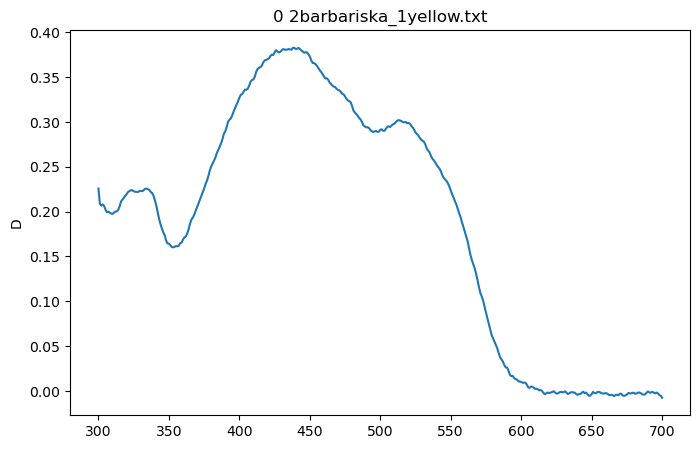

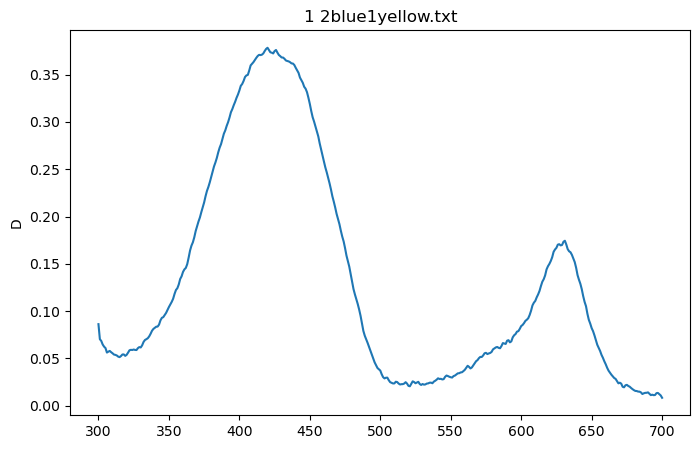

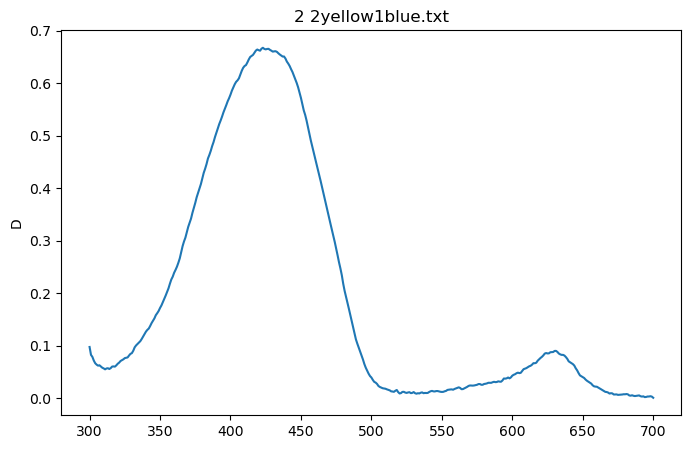

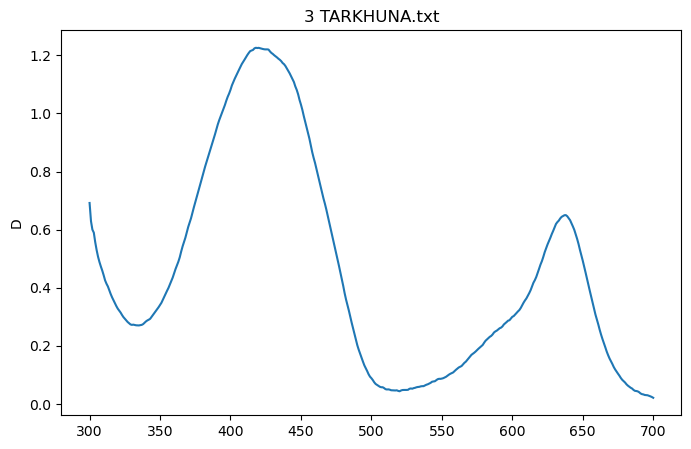

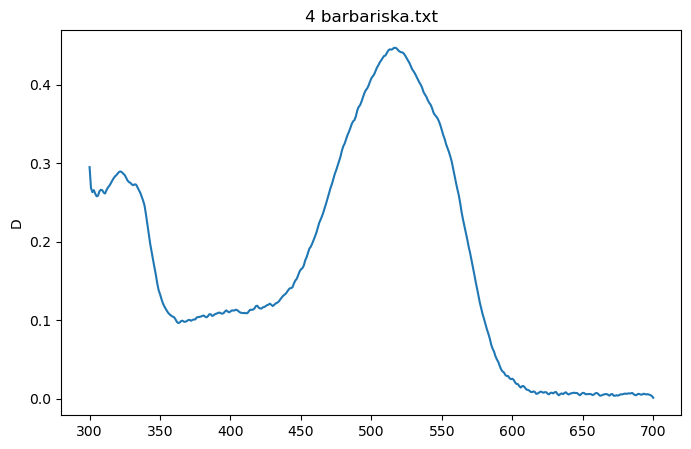

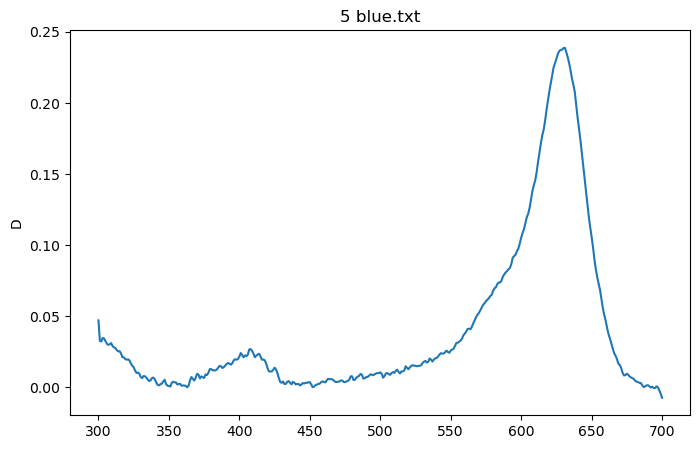

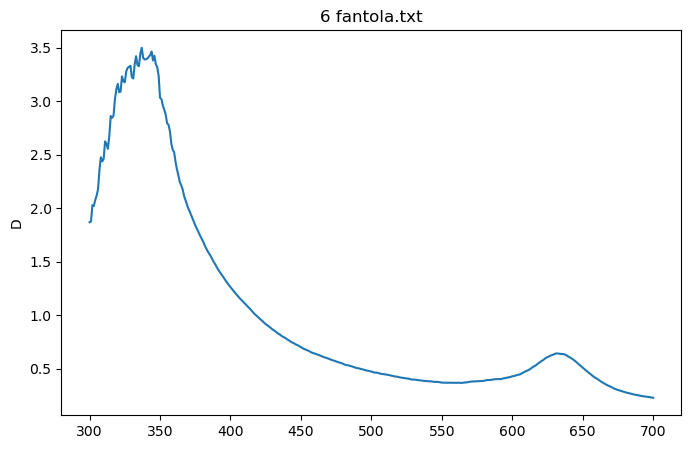

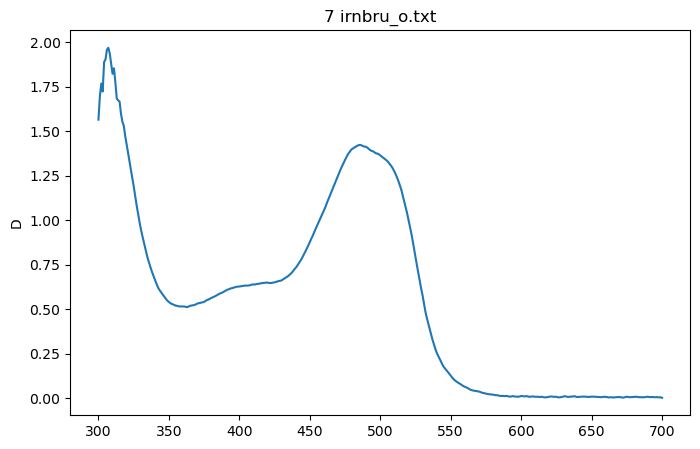

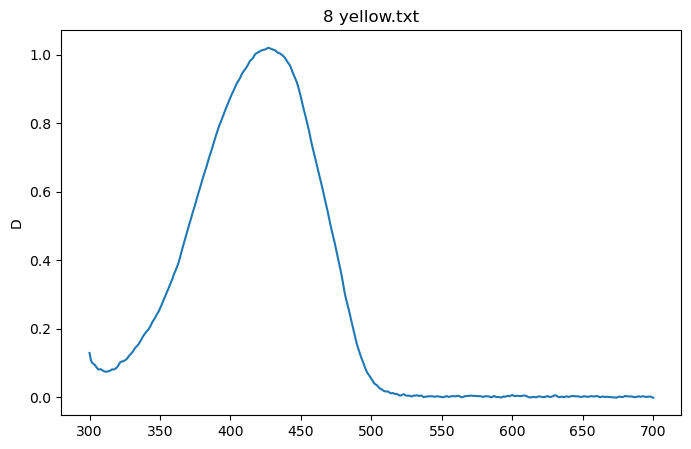

In [412]:
for i in range(len(file_data)):#Paint all datas
    N=len(file_data[i])
    x=[]
    y=[]
    for j in range(N):
        tmp = vfunc(file_data[i][j])
        x.append(tmp[0])
        y.append(tmp[1])
    plt.figure(figsize=(8, 5))
    to_paint.append(np.array(y))
    
    plt.plot(x,to_paint[i])
    plt.ylabel('D')
    plt.title(f'{i} {file_names[i]}')
    plt.show()
waveLength=np.array(x)

 In order to minimize the disturbance from spectres in UV area(Likely from Carbonhydrates), we will delete every data less than 350nm

In [413]:
mask = waveLength >= 350
waveLength = waveLength[mask]
for i in range(len(file_data)):
    to_paint[i] = to_paint[i][mask]

Use linear model to calculate theoretical spectres

In [414]:
yellow1blue2_teor = np.add(to_paint[8],np.multiply(to_paint[5],2))
yellow2blue1_teor = np.add(to_paint[1],np.multiply(to_paint[8],2))
yellow1barbariska2_teor = np.add(to_paint[8],np.multiply(to_paint[4],2))


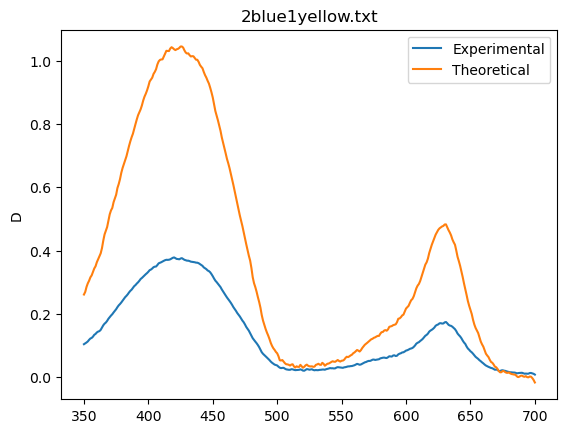

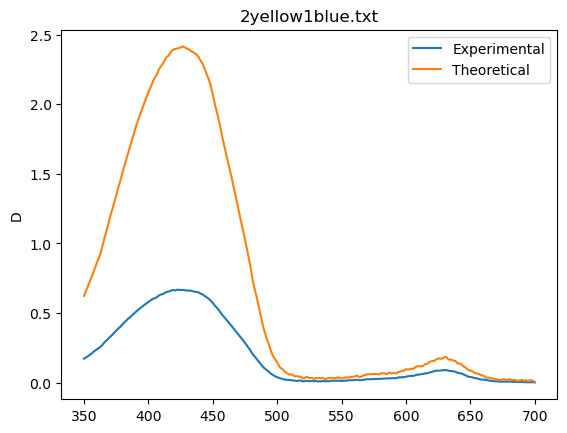

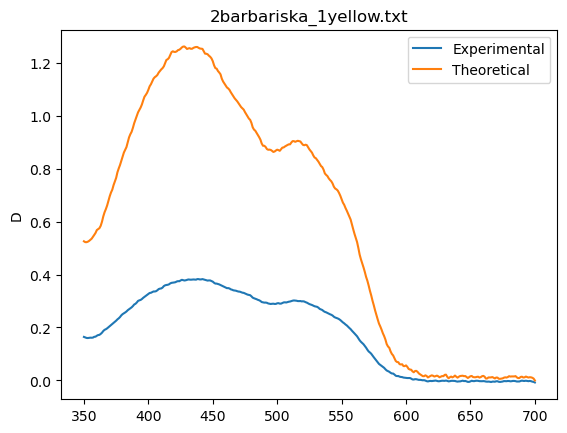

In [415]:
plt.plot(waveLength,to_paint[1],label="Experimental")
plt.plot(waveLength,yellow1blue2_teor,label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[1]}')
plt.show()

plt.plot(waveLength,to_paint[2],label="Experimental")
plt.plot(waveLength,yellow2blue1_teor,label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[2]}')
plt.show()


plt.plot(waveLength,to_paint[0],label="Experimental")
plt.plot(waveLength,yellow1barbariska2_teor,label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[0]}')
plt.show()


Calibration using Gradient Descent: loss=(A*D_{teor}-D_{expr})^2 (Least Square but NOT Least Square Method, HOW COULD I KNOW HOW TO WRITE LEAST SQUARE METHOD FOR THIS?)

In [416]:
gamma=1E-5#Learning rate
epsilon=0.001#Допустное значение
Nmax=int(1E5)
def loss(target_,input_,coeff_):
    return np.sum((coeff_*input_-target_)**2)

def dloss(target_,input_,coeff_):#Градиент(Наклон для 1Dim)
    return 2*np.sum(input_*(coeff_*input_-target_))

def train(target_,input_,coeff_):
    for i in range(Nmax):
        coeff_ -= gamma*dloss(target_,input_,coeff_)
        if loss(target_,input_,coeff_)<=epsilon:
            return coeff_
    return coeff_

coeff1=1
coeff2=1
coeff3=1
coeff1=train(to_paint[1],yellow1blue2_teor,coeff1)
coeff2=train(to_paint[2],yellow2blue1_teor,coeff2)
coeff3=train(to_paint[0],yellow1barbariska2_teor,coeff3)
print(coeff1)
print(coeff2)
print(coeff3)

0.36508996313646197
0.2774271909246518
0.3116880555943444


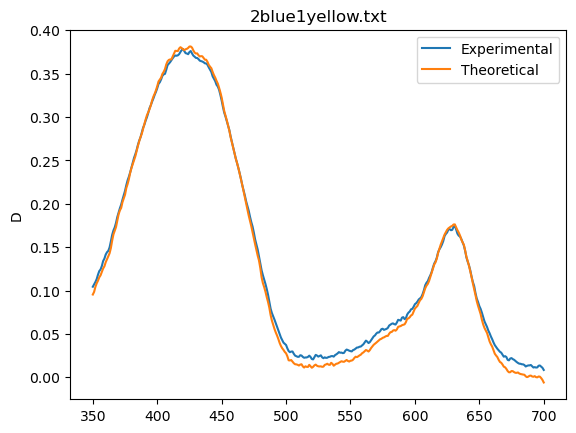

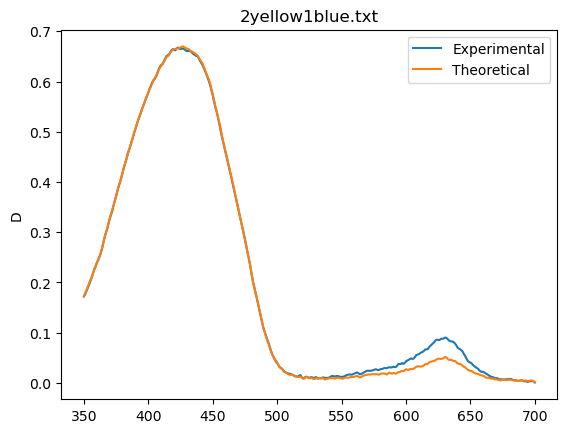

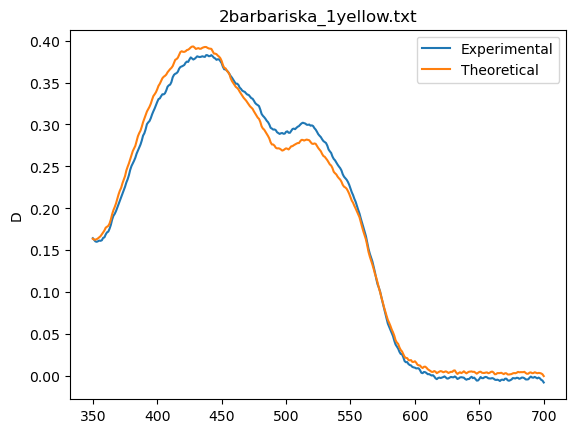

In [417]:
plt.plot(waveLength,to_paint[1],label="Experimental")
plt.plot(waveLength,yellow1blue2_teor*coeff1,label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[1]}')
plt.show()

plt.plot(waveLength,to_paint[2],label="Experimental")
plt.plot(waveLength,yellow2blue1_teor*coeff2,label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[2]}')
plt.show()


plt.plot(waveLength,to_paint[0],label="Experimental")
plt.plot(waveLength,yellow1barbariska2_teor*coeff3,label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[0]}')
plt.show()

Use yellow, barbariska, blue as basic colour. Model will be: D = cy Dy + cb Db + cbl Dbl, and loss = loss=(D(c)-D_{expr})^2

In [418]:
gamma=1E-5#Learning rate
epsilon=0.001#Допустное значение
Nmax=int(1E6)
def spectr(coeff_):
    return coeff_[0]*to_paint[8]+coeff_[1]*to_paint[4]+coeff_[2]*to_paint[5]

def loss3(target_,coeff1_,coeff2_,coeff3_):
    return np.sum((coeff1_*to_paint[8]+coeff2_*to_paint[4]+coeff3_*to_paint[5]-target_)**2)

def grdloss(target_,coeff1_,coeff2_,coeff3_):#Градиент
    tmp = 2*(coeff1_*to_paint[8]+coeff2_*to_paint[4]+coeff3_*to_paint[5]-target_)
    return [np.sum(to_paint[8]*tmp),np.sum(to_paint[4]*tmp),np.sum(to_paint[5]*tmp)]

def train3(target_,coeff1_,coeff2_,coeff3_):
    for i in range(Nmax):
        gradi = grdloss(target_,coeff1_,coeff2_,coeff3_)
        coeff1_ -= gamma*gradi[0]
        coeff2_ -= gamma*gradi[1]
        coeff3_ -= gamma*gradi[2]
        if loss3(target_,coeff1_,coeff2_,coeff3_)<=epsilon:
            return [coeff1_,coeff2_,coeff3_]
    return [coeff1_,coeff2_,coeff3_]

coef1=[1,1,1]
coef2=[1,1,1]
coef3=[1,1,1]
coef1=train3(to_paint[6],coef1[0],coef1[1],coef1[2])
coef2=train3(to_paint[3],coef2[0],coef2[1],coef2[2])
coef3=train3(to_paint[7],coef3[0],coef3[1],coef3[2])
print(coef1)
print(coef2)
print(coef3)

[1.1921954196097677, 0.9778221798207848, 3.2164593286307666]
[1.1700642717747303, 0.014751227176179408, 2.8471221919978285]
[0.5648020562177867, 2.1769100642442236, -0.5048573901874628]


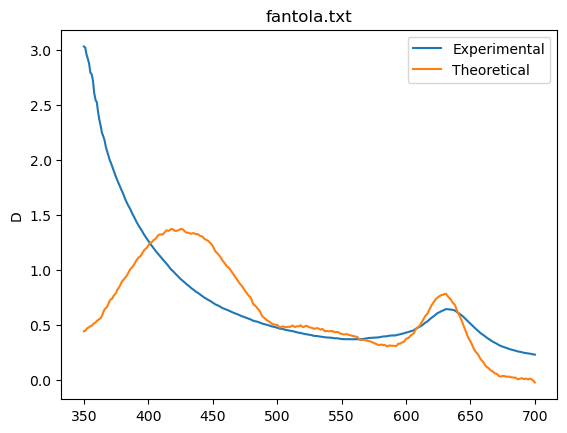

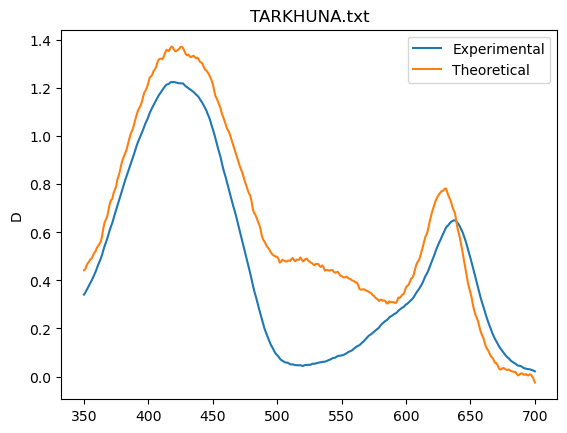

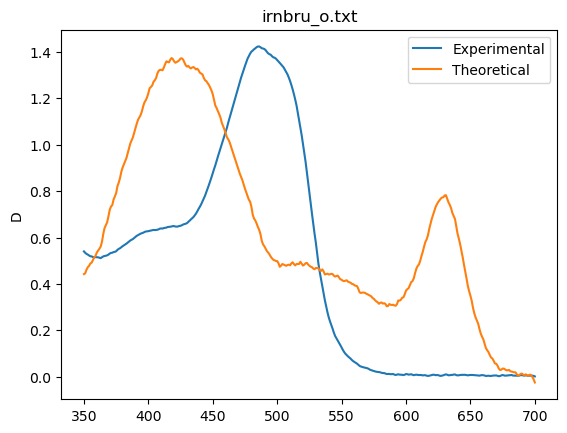

In [419]:
plt.plot(waveLength,to_paint[6],label="Experimental")
plt.plot(waveLength,spectr(coef1),label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[6]}')
plt.show()

plt.plot(waveLength,to_paint[3],label="Experimental")
plt.plot(waveLength,spectr(coef1),label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[3]}')
plt.show()


plt.plot(waveLength,to_paint[7],label="Experimental")
plt.plot(waveLength,spectr(coef1),label="Theoretical")
plt.legend()
plt.ylabel('D')
plt.title(f'{file_names[7]}')
plt.show()